In [10]:
from google.colab import files
uploaded = files.upload()

Saving q3_retail_promotions.csv to q3_retail_promotions (1).csv


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv('q3_retail_promotions.csv')

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [12]:
df = df.sort_values(by='transaction_date')

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (960, 13)
Test shape: (240, 13)


### Random Split is Not Suitable

A random split is inappropriate for time-series or time-ordered data because it can lead to data leakage, where future information is used to predict past outcomes.

By splitting data chronologically, we simulate real-world scenarios where models are trained on past data and used to predict future values, ensuring a more realistic evaluation.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

target = 'items_sold'

X_train = train_df.drop(columns=[target, 'transaction_date'])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, 'transaction_date'])
y_test = test_df[target]

categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)

Linear Regression RMSE: 27.12145116489062
Linear Regression MAE: 21.052926674588388


In [15]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 31.660007317329118
Random Forest MAE: 24.87391666666667


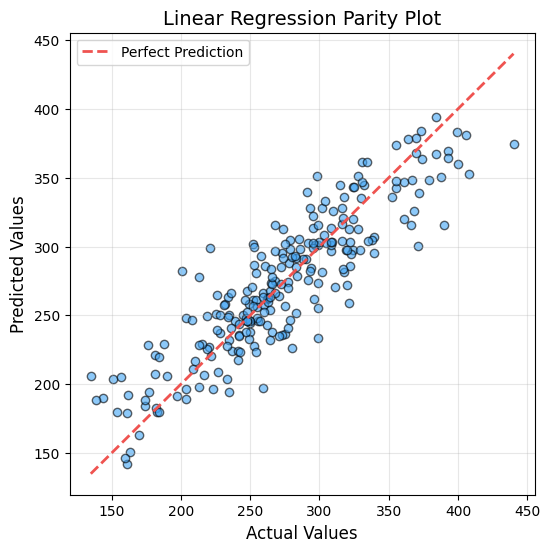

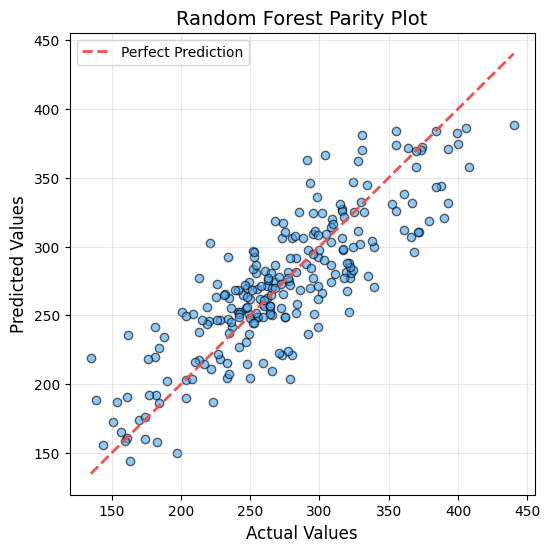

In [18]:
import matplotlib.pyplot as plt

def parity_plot(y_true, y_pred, title):
    plt.figure(figsize=(6,6))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.6,
        color='#42A5F5',
        edgecolor='black'
    )

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle='--',
        color='#EF5350',
        linewidth=2,
        label='Perfect Prediction'
    )


    plt.xlabel("Actual Values", fontsize=12)
    plt.ylabel("Predicted Values", fontsize=12)
    plt.title(title, fontsize=14)


    plt.grid(alpha=0.3)
    plt.legend()

    plt.show()

parity_plot(y_test, y_pred_lr, "Linear Regression Parity Plot")
parity_plot(y_test, y_pred_rf, "Random Forest Parity Plot")

In [17]:
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_cols)

all_features = list(encoded_cols) + numerical_cols

importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
7,store_size_small,0.183954
10,is_festival,0.174477
5,location_type_urban,0.140498
14,day_of_week,0.090612
9,is_weekend,0.063547
8,store_id,0.062056
6,store_size_medium,0.058178
11,competition_density,0.053486
13,month,0.040473
4,location_type_semi-urban,0.038886


### Feature Importance Interpretation

The top 5 most important features influencing items_sold are:

1. store_size_small  
2. is_festival  
3. location_type_urban  
4. day_of_week  
5. is_weekend  

These features indicate that both **store characteristics and temporal factors** significantly impact sales.

- **Store size** plays a crucial role, suggesting that smaller stores may have distinct sales patterns compared to larger ones.
- **Festival periods** strongly influence sales, indicating higher customer demand during special occasions.
- **Urban locations** tend to generate higher sales due to increased customer footfall.
- **Day of the week and weekends** highlight the importance of customer shopping behavior patterns, with certain days driving more sales than others.

Overall, the model shows that **sales are driven by a combination of store attributes, location, and time-based factors**, which can help businesses optimize promotions and inventory planning.

Festival and weekend effects suggest that targeted promotions during peak periods can significantly boost sales.